In [33]:
# %load_ext autoreload
# %autoreload 2

from pathlib import Path
import psutil
import datetime


from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats, signal

# from astropy import units
import tqdm
import polars as pl
from tqdm.notebook import tqdm as tqdm_notebook

from centrex_tlf import states, couplings, utils
from centrex_tlf.states import UncoupledBasisState, UncoupledState, ElectronicState
from centrex_tlf.hamiltonian import matrix_to_states
from state_prep.utils import calculate_transition_frequency
from state_prep.electric_fields import (
    ElectricField,
    Ez_from_csv,
)
from state_prep.hamiltonians import SlowHamiltonian
from state_prep.intensity_profiles import GaussianBeam, BackgroundField
from state_prep.magnetic_fields import MagneticField
from state_prep.microwaves import Polarization, MicrowaveField
from state_prep.simulator import Simulator
from state_prep.trajectory import Trajectory


In [2]:
plt.rcParams.update({"font.size": 14})

In [3]:
# fix memory leak warning from loky in joblib
import joblib.externals.loky

joblib.externals.loky.process_executor._MAX_MEMORY_LEAK_SIZE = int(5e10)

In [4]:
cwd = Path().cwd().absolute()
path_data = cwd / "results"


In [5]:
nr_cores = psutil.cpu_count(logical=False) + 2

rng = np.random.default_rng()


In [6]:
common_offset = 26.669e9  # Hz
measured_resonance = 26.6684e9  # Hz

## Define molecule trajectory
Defining the molecule trajectory as a Trajectory object. Specifying the initial position as z = 50 mm, i.e. 50mm  after the center of the microwaves is, and on the axis of the beamline. Taking the beam velocity to be 200 m/s in the z-direction. The simulation ends when `zfin` is reached, 200 mm from the microwwaves.

In [7]:
trajectory = Trajectory(
    Rini=np.array((0, 0, -80e-3)), Vini=np.array((0, 0, 200.0)), zfin=200e-3
)

## Define electric field
Defining an electric field that is an approximation of what the molecules should see in the real experiment.

In [8]:
# Define electric field based on finite element simulations
Ez = Ez_from_csv()
E_R = lambda R: np.array([0, 0, Ez(R[2])])


electric_field = ElectricField(E_R, trajectory.R_t)

Max electric field: 263.46 V/cm
Electric field at z = 1.125'': 109.24 V/cm


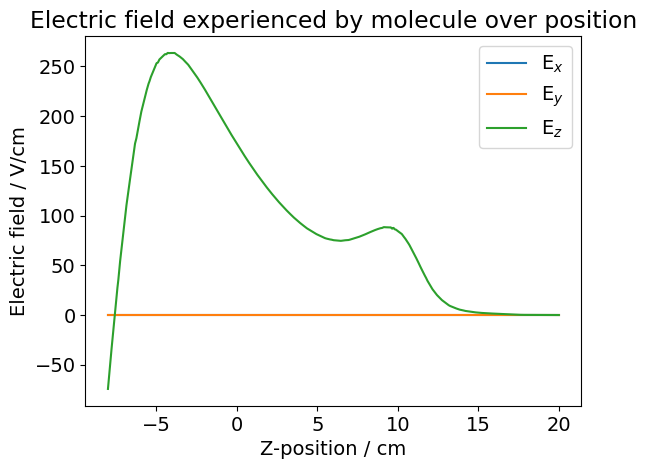

In [9]:
# Plot the electric field as a check:
ts, Es, ax = electric_field.plot(trajectory, position=True)

print(f"Max electric field: {np.max(Es):.2f} V/cm")
print(
    f"Electric field at z = 1.125'': {E_R(np.array([0, 0, 0.0254 * 1.125]))[2]:.2f} V/cm"
)

## Define magnetic field
Define the magnetic field. Using a constant field, either a nominal small field (so mF states become non-degenerate eigenstates of the Hamiltonian) or something resembilng Earth's magnetic field.

In [10]:
B = np.array((0, 0, 1e-3))


# B = np.array((0.2,0.45,0.1))
def B_R(R):
    if len(R.shape) == 1:
        return B
    else:
        return B.reshape((3, 1)) * np.ones(R.shape)


magnetic_field = MagneticField(B_R, R_t=trajectory.R_t)

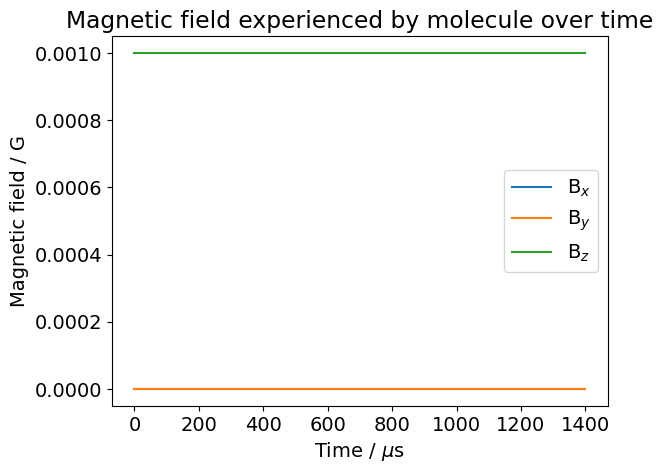

In [11]:
magnetic_field.plot(trajectory)

## Initial and final states
Define approximate initial states here.

In [12]:
from state_prep.approximate_states import (
    J1_singlet,
    J1_triplet_m,
    J1_triplet_0,
    J1_triplet_p,
    J2_singlet,
    J2_triplet_m,
    J2_triplet_0,
    J2_triplet_p,
)

initial_states_approx = [J1_singlet, J1_triplet_m, J1_triplet_0, J1_triplet_p]
final_states_approx = [J2_singlet, J2_triplet_m, J2_triplet_0, J2_triplet_p]

## Define molecule trajectory
Defining the molecule trajectory as a Trajectory object. Specifying the initial position as z = 50 mm, i.e. 50mm  after the center of the microwaves is, and on the axis of the beamline. Taking the beam velocity to be 200 m/s in the z-direction. The simulation ends when `zfin` is reached, 200 mm from the microwwaves.

In [13]:
trajectory = Trajectory(
    Rini=np.array((0, 0, -80e-3)), Vini=np.array((0, 0, 184.0)), zfin=200e-3
)

## Define slowly varying Hamiltonian
Define a Hamiltonian object that represents the slowly varying part of the Hamiltonian (i.e. everything except the microwaves). Using J = 0-3 here since we're interested in the time-evolution of J = 0 and 1 states; J = 0 and 3 are absolutely required since the electric field couples J = 0 to these, J = 3 is not strictly necessary. Since the Stark energies are << the rotational energies, we mostly just need the J of interest $\pm 1$.

In [14]:
Js = [0, 1, 2, 3]
hamiltonian = SlowHamiltonian(Js, trajectory, electric_field, magnetic_field)
# hamiltonian = SlowHamiltonianOld(0, 3, trajectory, electric_field, magnetic_field, '../hamiltonians/TlF_X_state_hamiltonian0to3_2020_03_03.pickle')

### J = 1 to 2 microwaves

In [21]:
# Define states
state1 = J1_triplet_0
state2 = J2_triplet_0

# Center position
R0 = np.array((0.00, 0, 0.0254 * 1.125))

#### Polarization:
# Define polarization components
p_x = np.array([1, 0, 0])
p_y = np.array([0, 1, 0])
p_z = np.array([0, 0, 1])

# Define a function that gives the main component of the polarization as a function of position
p_main = p_z
P_R = lambda R: p_main / np.sqrt(np.sum(p_main**2))

# Define k-vector
k = np.array((1, 0, 0))
pol = Polarization(P_R, k, f_long=1)

#### Frequency
# Calculate the microwave frequency between specified states at a specific point
muW_freq_2 = calculate_transition_frequency(
    state1, state2, hamiltonian.H_R(R0), hamiltonian.QN
)
print(
    f"Electric field at SPA2 center {electric_field.E_R(R0)[-1]:.2f} V/m @ {R0[2] * 1e3:.2f} mm"
)
print(f"Transition frequency at center of SPA2 microwaves: {muW_freq_2 / 1e9:.5f} GHz")

#### Intensity profile:
# Define a Gaussian intensity profile
intensity = GaussianBeam(
    power=0.5e-3,
    sigma=25.4e-3 / (2 * np.sqrt(2 * np.log(2))),
    R0=R0,
    k=k,
    freq=muW_freq_2,
)

#### Define MicrowaveField
mf12 = MicrowaveField(1, 2, intensity, pol, muW_freq_2, QN=hamiltonian.QN)

Electric field at SPA2 center 109.24 V/m @ 28.57 mm
Transition frequency at center of SPA2 microwaves: 26.66881 GHz


In [ ]:
eigh = np.linalg.eigh(hamiltonian.H_R(R0))
sv1 = state1.state_vector(hamiltonian.QN)
overlaps1 = np.abs(sv1.conj().T @ eigh.eigenvectors)
id1 = int(np.argmax(overlaps1))
sv2 = state2.state_vector(hamiltonian.QN)
overlaps2 = np.abs(sv2.conj().T @ eigh.eigenvectors)
id2 = int(np.argmax(overlaps2))

14 35 26.668808190958444


In [58]:
states_AP2_center = matrix_to_states(eigh.eigenvectors, hamiltonian.QN)
print("==== J=1 ===")
print(states_AP2_center[id1].remove_small_components(1e-2))
print("==== J=2 ===")
print(states_AP2_center[id2].remove_small_components(1e-2))
print("")
print(
    id1,
    id2,
    round(
        eigh.eigenvalues[id2] / (2 * np.pi * 1e9)
        - eigh.eigenvalues[id1] / (2 * np.pi * 1e9),
        4,
    ),
    "GHz",
)

==== J=1 ===
0.71+0.00j x |J = 1, mJ = 0, I₁ = 1/2, m₁ = -1/2, I₂ = 1/2, m₂ = 1/2, P = -, Ω = 0>
0.70+0.00j x |J = 1, mJ = 0, I₁ = 1/2, m₁ = 1/2, I₂ = 1/2, m₂ = -1/2, P = -, Ω = 0>
0.05+0.00j x |J = 1, mJ = -1, I₁ = 1/2, m₁ = 1/2, I₂ = 1/2, m₂ = 1/2, P = -, Ω = 0>
0.05+0.00j x |J = 1, mJ = 1, I₁ = 1/2, m₁ = -1/2, I₂ = 1/2, m₂ = -1/2, P = -, Ω = 0>
==== J=2 ===
0.60+0.00j x |J = 2, mJ = 0, I₁ = 1/2, m₁ = 1/2, I₂ = 1/2, m₂ = -1/2, P = +, Ω = 0>
0.60+0.00j x |J = 2, mJ = 0, I₁ = 1/2, m₁ = -1/2, I₂ = 1/2, m₂ = 1/2, P = +, Ω = 0>
0.38+0.00j x |J = 2, mJ = 1, I₁ = 1/2, m₁ = -1/2, I₂ = 1/2, m₂ = -1/2, P = +, Ω = 0>
0.38+0.00j x |J = 2, mJ = -1, I₁ = 1/2, m₁ = 1/2, I₂ = 1/2, m₂ = 1/2, P = +, Ω = 0>

14 35 26.6688 GHz


### J = 1 to 2 background field
Defining a field that has uniform intensity everywhere to represent microwaves randomly scattering of the vacuum chamber, windows etc

In [16]:
#### Polarization:
# Define polarization components
p_x = np.array([1, 0, 0])
p_y = np.array([0, 1, 0])
p_z = np.array([0, 0, 1])

# Define a function that gives the main component of the polarization as a function of position
p = p_z + 0.4 * p_y
P_R = lambda R: p / np.sqrt(np.sum(p**2))


pol_bg = Polarization(P_R)

# in reality left of the J=0->J=1 microwave there is no population in J=1 yet, so I should set the
# background field to zero there using lims, using 2 sigma of the J=0->J=1 microwave beam
lims = [
    (-1, 1),
    (-1, 1),
    (+25.4e-3 / (2 * np.sqrt(2 * np.log(2))), 1),
]
intensity_bg = BackgroundField(lims, intensity=mf12.intensity.I_R(R0) / 20)

#### Define MicrowaveField
mf12_bg = MicrowaveField(
    1, 2, intensity_bg, pol_bg, muW_freq_2, hamiltonian.QN, background_field=True
)

# Scan J12 frequency with BG field Z pol

## Constant BG intensity

In [17]:
#### Polarization:
# Define polarization components
p_x = np.array([1, 0, 0])
p_y = np.array([0, 1, 0])
p_z = np.array([0, 0, 1])

# Define a function that gives the main component of the polarization as a function of position
p = p_z
P_R = lambda R: p / np.sqrt(np.sum(p**2))


pol_bg = Polarization(P_R)

# in reality left of the J=0->J=1 microwave there is no population in J=1 yet, so I should set the
# background field to zero there using lims, using 2 sigma of the J=0->J=1 microwave beam
lims = [
    (-1, 1),
    (-1, 1),
    (+25.4e-3 / (2 * np.sqrt(2 * np.log(2))), 1),
]
intensity_bg = BackgroundField(lims, intensity=mf12.intensity.I_R(R0) / 20)

#### Define MicrowaveField
mf12_bg = MicrowaveField(
    1, 2, intensity_bg, pol_bg, muW_freq_2, hamiltonian.QN, background_field=True
)

In [18]:
monitor_states = [
    J2_singlet,
    states.CoupledBasisState(
        J=2,
        F1=3 / 2,
        F=1,
        mF=0,
        electronic_state=ElectronicState.X,
        I1=1 / 2,
        I2=1 / 2,
        P=1,
    ).transform_to_uncoupled(),
    J2_triplet_m,
    J2_triplet_p,
]

In [19]:
from state_prep.utils import find_max_overlap_idx


def combine_simulation_batches(
    res_batch: list[
        tuple[
            np.ndarray,  # power_spa2
            np.ndarray,  # bg_fraction
            np.ndarray,  # detunings
            float,  # v_forward
            np.ndarray,  # prob_ini
            np.ndarray,  # prob_fin
            list[np.ndarray],  # prob_monitor_states
        ]
    ],
) -> tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
    float,
    np.ndarray,
    np.ndarray,
    list[np.ndarray],
]:
    """
    Combine joblib batch results from `run_simulation_batch` into a single result tuple.

    Returns:
        (
            power_spa2,
            bg_fraction,
            detunings,
            v_forward,
            prob_ini,
            prob_fin,
            prob_monitor_states,
        )
    """

    if len(res_batch) == 0:
        raise ValueError("res_batch is empty")

    (
        powers_list,
        bg_fractions_list,
        detunings_list,
        v_forward_list,
        prob_ini_list,
        prob_fin_list,
        prob_monitor_states_list,
    ) = zip(*res_batch)

    # Scalars (assumed identical across batches)
    v_forward = v_forward_list[0]

    # Concatenate 1D arrays
    power_spa2 = np.concatenate(powers_list)
    bg_fraction = np.concatenate(bg_fractions_list)
    detunings = np.concatenate(detunings_list)

    prob_ini = np.concatenate(prob_ini_list)
    prob_fin = np.concatenate(prob_fin_list)

    # Monitor states: list of arrays, one per monitor state
    n_monitor = len(prob_monitor_states_list[0])

    prob_monitor_states = np.array(
        [
            np.concatenate([batch[i] for batch in prob_monitor_states_list])
            for i in range(n_monitor)
        ]
    )

    return (
        power_spa2,
        bg_fraction,
        detunings,
        v_forward,
        prob_ini,
        prob_fin,
        prob_monitor_states,
    )


def run_simulation_batch(
    power_spa2: np.ndarray,
    bg_fraction: np.ndarray,
    detunings: np.ndarray,
    v_forward: float,
    initial_state_idx: int,
    initial_states_approx: list[states.UncoupledState],
    target_state: states.UncoupledState | list[states.UncoupledState],
    monitor_states: list[states.UncoupledState] = [],
    N_steps=10_000,
) -> tuple[float, float, float, float, float, float, list[float]]:
    """
    Runs the simulation for one value of power and finds the probability of ending up in the target state.
    """

    mf12.set_frequency(muW_freq_2)
    mf12_bg.set_frequency(muW_freq_2)

    # set powers & intensities
    mf12.set_power(power_spa2[0])
    mf12_bg.intensity.intensity = (
        mf12.intensity.I_R(np.array([0.00, 0, 0.0254 * 1.125])) * bg_fraction[0]
    )

    # Run the simulator
    microwave_fields = [mf12, mf12_bg]

    # # trajectories
    trajectory.Vini[-1] = v_forward

    # pickle problem occurs here
    simulator = Simulator(
        trajectory,
        electric_field,
        magnetic_field,
        initial_states_approx,
        hamiltonian,
        microwave_fields,
    )

    if bg_fraction[0] != 0:
        intensity_prefactors = np.array(
            [power_spa2 / power_spa2[0], bg_fraction / bg_fraction[0]]
        ).T
    else:
        intensity_prefactors = np.array([power_spa2 / power_spa2[0], bg_fraction]).T

    result = simulator.run_microwave_scan(
        detunings_hz=detunings,
        intensity_prefactors=intensity_prefactors,
        N_steps=N_steps,
        monitor_states=monitor_states,
        progress=False,
    )

    init_idx = find_max_overlap_idx(
        initial_states_approx[2].state_vector(simulator.hamiltonian.QN), result.V_ini
    )
    prob_ini = result.probabilities_final[:, initial_state_idx, init_idx]

    # Determine probability to be in target state
    if isinstance(target_state, states.UncoupledState):
        target_state = [target_state]

    prob_fin = np.zeros(prob_ini.shape)
    for ts in target_state:
        final_idx = find_max_overlap_idx(
            ts.state_vector(simulator.hamiltonian.QN), result.V_ini
        )
        prob_fin += result.probabilities_final[:, initial_state_idx, final_idx]

    prob_monitor_states = []
    for monitor_state in monitor_states:
        monitor_idx = find_max_overlap_idx(
            monitor_state.state_vector(simulator.hamiltonian.QN), result.V_ini
        )
        prob_monitor_states.append(
            result.probabilities_final[:, initial_state_idx, monitor_idx]
        )

    return (
        power_spa2,
        bg_fraction,
        detunings,
        v_forward,
        prob_ini,
        prob_fin,
        np.array(prob_monitor_states),
    )

In [20]:
detunings = np.linspace(-2, 1.5, 25) * 1e6

detunings_batch = np.array([detunings, detunings]).T
powers_batch = np.ones(detunings.shape) * 5e-5
bg_fractions_batch = np.ones(detunings.shape) * 1 / 35

res_batch = Parallel(n_jobs=nr_cores, verbose=1)(
    delayed(run_simulation_batch)(
        powers,
        bg_fractions,
        detuning,
        184,
        2,
        initial_states_approx,
        J2_triplet_0,
        monitor_states,
        6_000,
    )
    for detuning, powers, bg_fractions in zip(
        np.array_split(detunings_batch, nr_cores),
        np.array_split(powers_batch, nr_cores),
        np.array_split(bg_fractions_batch, nr_cores),
    )
)
res_batch = combine_simulation_batches(res_batch)


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.


KeyboardInterrupt: 

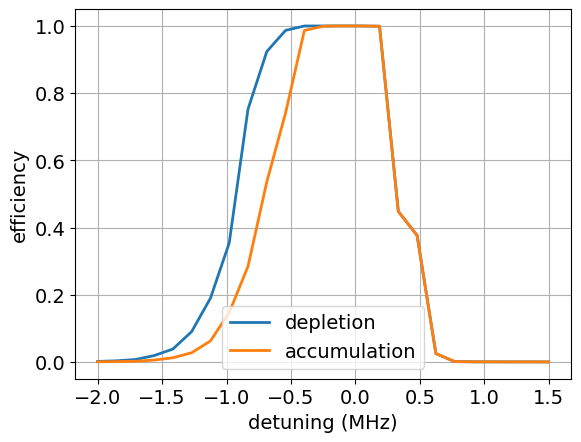

In [ ]:
fig, ax = plt.subplots()

ax.plot(detunings / 1e6, 1 - res_batch[4], lw=2, label="depletion")
ax.plot(detunings / 1e6, res_batch[5], lw=2, label="accumulation")

ax.set_xlabel("detuning (MHz)")
ax.set_ylabel("efficiency")

ax.legend()
ax.grid()

In [ ]:
label_monitor = [
    s.transform_to_coupled().largest.state_string_custom(["F1", "F", "mF"])
    for s in monitor_states
]

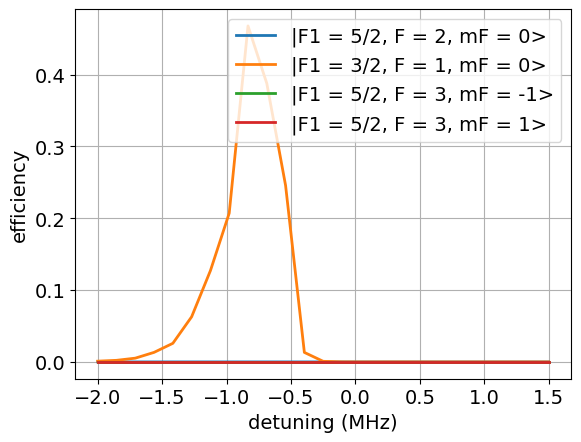

In [ ]:
fig, ax = plt.subplots()

ax.plot(detunings / 1e6, res_batch[6].T, lw=2, label=label_monitor)

ax.set_xlabel("detuning (MHz)")
ax.set_ylabel("efficiency")

ax.legend()
ax.grid()

In [ ]:
pop_detected = res_batch[5]
pop_detected += res_batch[6][-2]
pop_detected += res_batch[6][-1]
pop_monitor = res_batch[6].T
pop_transferred = res_batch[-2] + pop_monitor.sum(axis=1)

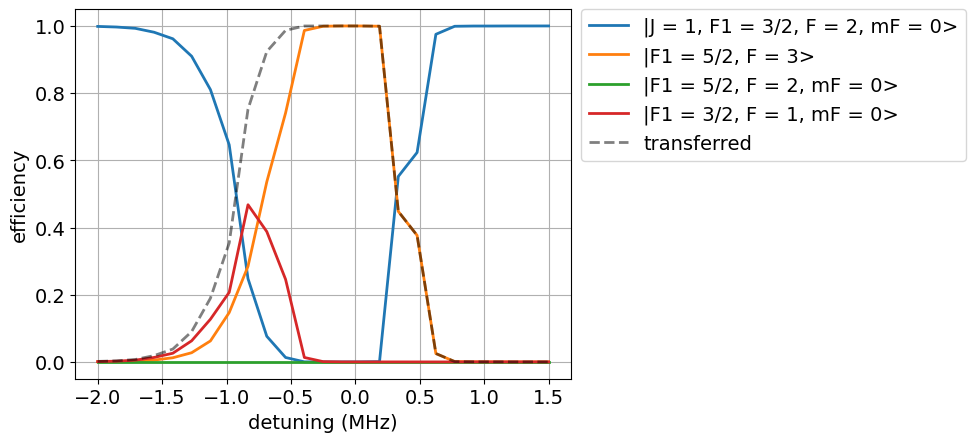

In [ ]:
fig, ax = plt.subplots()

ax.plot(
    detunings / 1e6,
    res_batch[-3],
    lw=2,
    label="|J = 1, F1 = 3/2, F = 2, mF = 0>",
)
ax.plot(detunings / 1e6, pop_detected, lw=2, label="|F1 = 5/2, F = 3>")

ax.plot(detunings / 1e6, pop_monitor[:, :-2], lw=2, label=label_monitor[:-2])

ax.plot(
    detunings / 1e6, pop_transferred, "k", lw=2, ls="--", alpha=0.5, label="transferred"
)


ax.set_xlabel("detuning (MHz)")
ax.set_ylabel("efficiency")

ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.grid()

In [ ]:
paper_offset = muW_freq_2 - common_offset

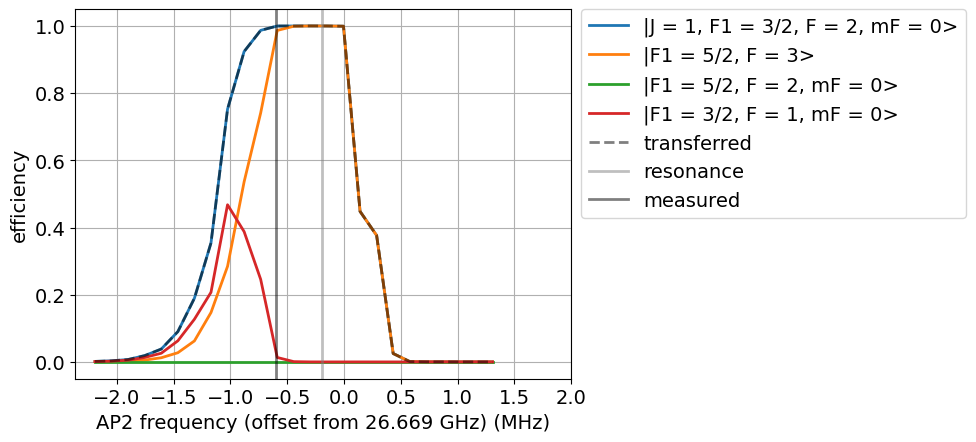

In [ ]:
fig, ax = plt.subplots()

ax.plot(
    (detunings + paper_offset) / 1e6,
    1 - res_batch[4],
    lw=2,
    label="|J = 1, F1 = 3/2, F = 2, mF = 0>",
)
ax.plot((detunings + paper_offset) / 1e6, pop_detected, lw=2, label="|F1 = 5/2, F = 3>")

ax.plot(
    (detunings + paper_offset) / 1e6,
    pop_monitor[:, :-2],
    lw=2,
    label=label_monitor[:-2],
)

ax.plot(
    (detunings + paper_offset) / 1e6,
    pop_transferred,
    "k",
    lw=2,
    ls="--",
    alpha=0.5,
    label="transferred",
)

ax.axvline(paper_offset / 1e6, color="gray", lw=2, alpha=0.5, label="resonance")

ax.axvline(
    (measured_resonance - common_offset) / 1e6,
    color="black",
    lw=2,
    alpha=0.5,
    label="measured",
)

ax.set_xticks(np.arange(-2.0, 2.5, 0.5))

ax.set_xlabel("AP2 frequency (offset from 26.669 GHz) (MHz)")
ax.set_ylabel("efficiency")

ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.grid()

In [ ]:
import pandas as pd

initial_pop = res_batch[4]
final_pop = res_batch[5]

df = pd.DataFrame(
    {
        "frequency [MHz]": (detunings + muW_freq_2) / 1e6,
        "detuning [MHz]": detunings / 1e6,
        "pop initial": initial_pop,
        "pop final": final_pop,
        label_monitor[0]: pop_monitor[:, 0],
        label_monitor[1]: pop_monitor[:, 1],
        label_monitor[2]: pop_monitor[:, 2],
        label_monitor[3]: pop_monitor[:, 3],
    }
)

df.to_csv(path_data / "SPA2_power_scan_simulation_paper_comparison.csv", index=False)


In [ ]:
def make_detuning_power_scan(
    detunings: np.ndarray,
    powers_spa2: np.ndarray,
    bg_ratio: float,
    *,
    order: str = "C",
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Build a full scan over (detuning, power_spa2) combinations.

    Args:
        detunings: 1D array of detunings (Hz), shape (nd,).
        powers_spa2: 1D array of powers (W), shape (np,).
        bg_ratio: bg power = bg_ratio * spa2 power.
        order: "C" => detunings vary fastest within each power.
               "F" => powers vary fastest within each detuning.

    Returns:
        detunings_scan: shape (n, 2)
        powers_spa2_scan: shape (n,)
        bg_fractions_scan: shape (n,) (actual bg power array, derived but still an array)
    """
    detunings = np.asarray(detunings, dtype=float)
    powers_spa2 = np.asarray(powers_spa2, dtype=float)

    if detunings.ndim != 1:
        raise ValueError("detunings must be 1D")
    if powers_spa2.ndim != 1:
        raise ValueError("powers_spa2 must be 1D")
    if order not in ("C", "F"):
        raise ValueError("order must be 'C' or 'F'")

    D, P = np.meshgrid(detunings, powers_spa2, indexing="xy")  # both (np, nd)

    if order == "C":
        detunings_scan = D.ravel(order="C")
        powers_spa2_scan = P.ravel(order="C")
    else:
        detunings_scan = D.ravel(order="F")
        powers_spa2_scan = P.ravel(order="F")

    bg_fractions_scan = np.ones(powers_spa2_scan.shape) * bg_ratio

    detunings_scan = np.column_stack([detunings_scan, detunings_scan])
    return detunings_scan, powers_spa2_scan, bg_fractions_scan

In [ ]:
detunings = np.linspace(-2e6, 1e6, 15)
powers_spa2 = np.array([5e-6, 1e-5, 2e-5, 5e-5])
detunings_batch, powers_batch, bg_fractions_batch = make_detuning_power_scan(
    detunings, powers_spa2, 1 / 35
)

res_batch = Parallel(n_jobs=nr_cores, verbose=1)(
    delayed(run_simulation_batch)(
        powers,
        bg_fractions,
        detuning,
        184,
        2,
        initial_states_approx,
        J2_triplet_0,
        monitor_states,
        6_000,
    )
    for detuning, powers, bg_fractions in zip(
        np.array_split(detunings_batch, nr_cores),
        np.array_split(powers_batch, nr_cores),
        np.array_split(bg_fractions_batch, nr_cores),
    )
)
res_batch = combine_simulation_batches(res_batch)

pop_initial = res_batch[4].reshape(-1, detunings.size).T
pop_final = res_batch[5].reshape(-1, detunings.size).T
pop_monitor = res_batch[6].reshape(len(monitor_states), -1, detunings.size).T
pop_detected = pop_final + pop_monitor[:, :, -2:].sum(axis=2)


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   2 out of  10 | elapsed:   19.9s remaining:  1.3min
[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed:   20.1s finished


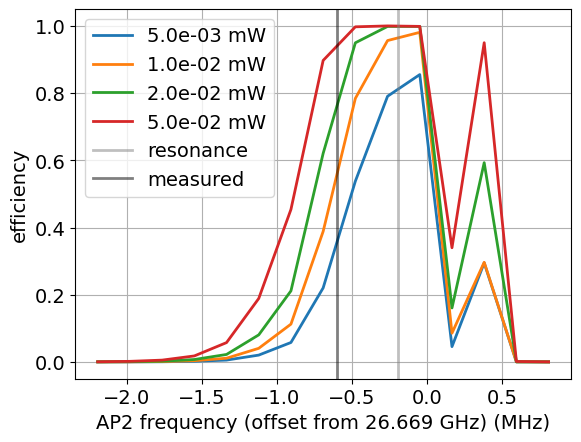

In [ ]:
labels: list[str] = [f"{p * 1e3:.1e} mW" for p in powers_spa2]
fig, ax = plt.subplots()

ax.plot(
    (detunings + paper_offset) / 1e6,
    pop_detected,
    lw=2,
    label=labels,
)

ax.axvline(paper_offset / 1e6, color="gray", lw=2, alpha=0.5, label="resonance")

ax.axvline(
    (measured_resonance - common_offset) / 1e6,
    color="black",
    lw=2,
    alpha=0.5,
    label="measured",
)

ax.set_xlabel("AP2 frequency (offset from 26.669 GHz) (MHz)")
ax.set_ylabel("efficiency")
ax.legend()
ax.grid()

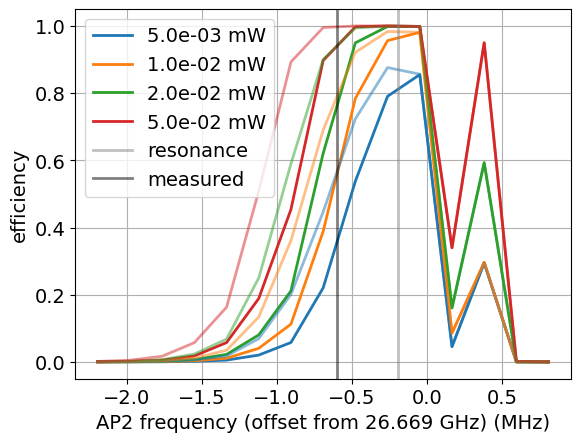

In [ ]:
fig, ax = plt.subplots()

clines = ax.plot(
    (detunings + paper_offset) / 1e6,
    pop_detected,
    lw=2,
    label=labels,
)

for cline, y in zip(clines, 1 - pop_initial.T):
    ax.plot(
        (detunings + paper_offset) / 1e6,
        y,
        lw=2,
        color=cline.get_color(),
        alpha=0.5,
    )

ax.axvline(paper_offset / 1e6, color="gray", lw=2, alpha=0.5, label="resonance")

ax.axvline(
    (measured_resonance - common_offset) / 1e6,
    color="black",
    lw=2,
    alpha=0.5,
    label="measured",
)

ax.set_xlabel("AP2 frequency (offset from 26.669 GHz) (MHz)")
ax.set_ylabel("efficiency")
ax.legend()
ax.grid()

## No BG

In [ ]:
detunings = np.linspace(-2e6, 1e6, 25)
powers_spa2 = np.array([5e-5])
detunings_batch, powers_batch, bg_fractions_batch = make_detuning_power_scan(
    detunings, powers_spa2, 0.0
)

res_batch = Parallel(n_jobs=nr_cores, verbose=1)(
    delayed(run_simulation_batch)(
        powers,
        bg_fractions,
        detuning,
        184,
        2,
        initial_states_approx,
        J2_triplet_0,
        monitor_states,
        6_000,
    )
    for detuning, powers, bg_fractions in zip(
        np.array_split(detunings_batch, nr_cores),
        np.array_split(powers_batch, nr_cores),
        np.array_split(bg_fractions_batch, nr_cores),
    )
)
res_batch = combine_simulation_batches(res_batch)

pop_initial = res_batch[4].reshape(-1, detunings.size).T.flatten()
pop_final = res_batch[5].reshape(-1, detunings.size).T.flatten()
pop_monitor = res_batch[6].reshape(len(monitor_states), -1, detunings.size).T[:, 0, :]
pop_detected = (pop_final + pop_monitor[:, -2:].sum(axis=1)).flatten()


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   2 out of  10 | elapsed:    9.7s remaining:   39.2s
[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed:   12.4s finished


In [ ]:
paper_offset = muW_freq_2 - common_offset

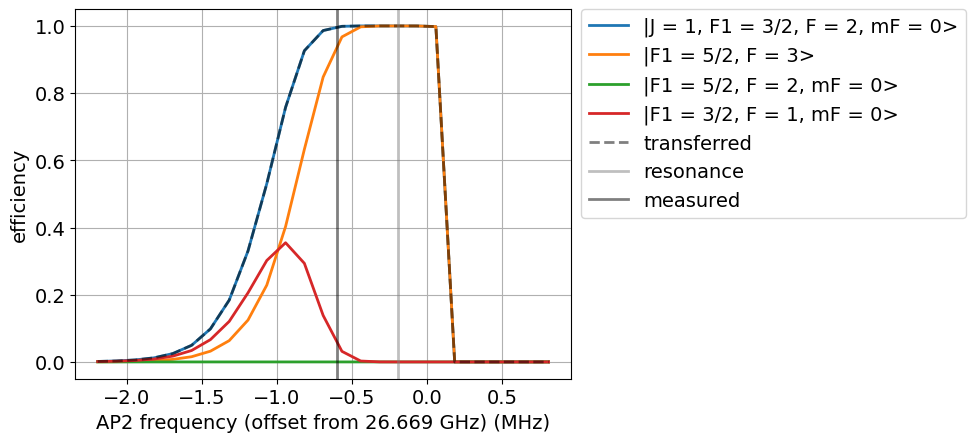

In [ ]:
fig, ax = plt.subplots()

ax.plot(
    (detunings + paper_offset) / 1e6,
    1 - pop_initial,
    lw=2,
    label="|J = 1, F1 = 3/2, F = 2, mF = 0>",
)
ax.plot((detunings + paper_offset) / 1e6, pop_detected, lw=2, label="|F1 = 5/2, F = 3>")

ax.plot(
    (detunings + paper_offset) / 1e6,
    pop_monitor[:, :-2],
    lw=2,
    label=label_monitor[:-2],
)

ax.plot(
    (detunings + paper_offset) / 1e6,
    pop_monitor.sum(axis=1) + pop_final,
    "k",
    lw=2,
    ls="--",
    alpha=0.5,
    label="transferred",
)

ax.axvline(paper_offset / 1e6, color="gray", lw=2, alpha=0.5, label="resonance")

ax.axvline(
    (measured_resonance - common_offset) / 1e6,
    color="black",
    lw=2,
    alpha=0.5,
    label="measured",
)

ax.set_xlabel("AP2 frequency (offset from 26.669 GHz) (MHz)")
ax.set_ylabel("efficiency")

ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.grid()

In [ ]:
detunings = np.linspace(-2e6, 1e6, 25)
powers_spa2 = np.array([5e-6, 1e-5, 2e-5, 5e-5])
detunings_batch, powers_batch, bg_fractions_batch = make_detuning_power_scan(
    detunings, powers_spa2, 0.0
)

res_batch = Parallel(n_jobs=nr_cores, verbose=1)(
    delayed(run_simulation_batch)(
        powers,
        bg_fractions,
        detuning,
        184,
        2,
        initial_states_approx,
        J2_triplet_0,
        monitor_states,
        6_000,
    )
    for detuning, powers, bg_fractions in zip(
        np.array_split(detunings_batch, nr_cores),
        np.array_split(powers_batch, nr_cores),
        np.array_split(bg_fractions_batch, nr_cores),
    )
)
res_batch = combine_simulation_batches(res_batch)

pop_initial = res_batch[4].reshape(-1, detunings.size).T
pop_final = res_batch[5].reshape(-1, detunings.size).T
pop_monitor = res_batch[6].reshape(len(monitor_states), -1, detunings.size).T
pop_detected = pop_final + pop_monitor[:, -2:].sum(axis=1)


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
c:\Users\ogras\Documents\GitHub\centrex-state-prep\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=10)]: Done   2 out of  10 | elapsed:   30.2s remaining:  2.0min
[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed:   30.8s finished


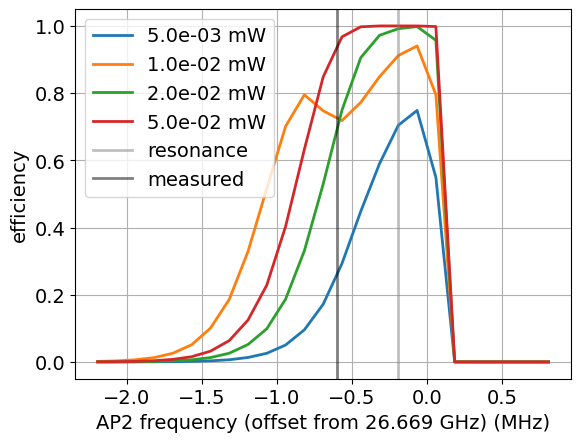

In [ ]:
labels: list[str] = [f"{p * 1e3:.1e} mW" for p in powers_spa2]
fig, ax = plt.subplots()

ax.plot(
    (detunings + paper_offset) / 1e6,
    pop_detected,
    lw=2,
    label=labels,
)

ax.axvline(paper_offset / 1e6, color="gray", lw=2, alpha=0.5, label="resonance")

ax.axvline(
    (measured_resonance - common_offset) / 1e6,
    color="black",
    lw=2,
    alpha=0.5,
    label="measured",
)

ax.set_xlabel("AP2 frequency (offset from 26.669 GHz) (MHz)")
ax.set_ylabel("efficiency")
ax.legend()
ax.grid()

## Constant BG intensity velocity averaged

In [ ]:
#### Intensity profile:
lims = [
    (-1, 1),
    (-1, 1),
    (+25.4e-3 / (2 * np.sqrt(2 * np.log(2))), 1),
]
intensity_bg = BackgroundField(lims, intensity=mf12.intensity.I_R(R0) / 20)

#### Define MicrowaveField
mf12_bg = MicrowaveField(
    1, 2, intensity_bg, pol_bg, muW_freq_2, hamiltonian.QN, background_field=True
)

In [ ]:
velocities = np.linspace(184 - 16 * 2, 184 + 16 * 2, 11)

detunings = np.linspace(-2, 1.5, 25) * 1e6

detunings_batch = np.array([detunings, detunings]).T
bg_fractions_batch = np.ones(detunings.shape) * 1 / 30
powers_batch = np.ones(detunings.shape) * 5e-5

res_velocity = []
for vel in velocities:
    res_batch = Parallel(n_jobs=nr_cores, verbose=0)(
        delayed(run_simulation_batch)(
            powers,
            bg_fractions,
            detuning,
            vel,
            2,
            initial_states_approx,
            J2_triplet_0,
            monitor_states,
            7_000,
        )
        for detuning, powers, bg_fractions in zip(
            np.array_split(detunings_batch, nr_cores),
            np.array_split(powers_batch, nr_cores),
            np.array_split(bg_fractions_batch, nr_cores),
        )
    )
    res_batch = combine_simulation_batches(res_batch)

    res_velocity.append((vel, res_batch))

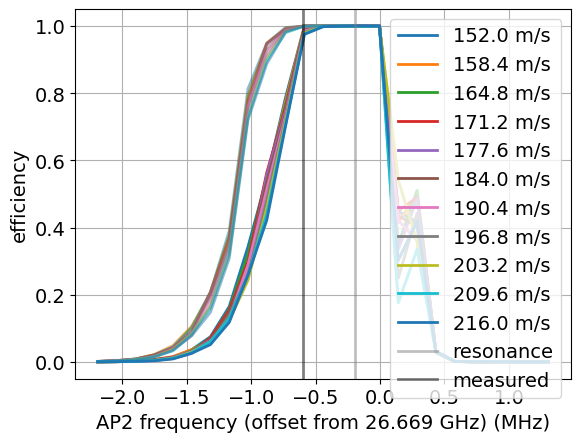

In [ ]:
fig, ax = plt.subplots()

for vel, res in res_velocity:
    pop_initial = res[4]
    pop_detected = np.array(res[-2])
    pop_detected += np.array(res[-1][-2])
    pop_detected += np.array(res[-1][-1])

    clines = ax.plot(
        (detunings + paper_offset) / 1e6,
        pop_detected,
        lw=2,
        label=f"{vel:.1f} m/s",
    )

    clines = ax.plot(
        (detunings + paper_offset) / 1e6,
        1 - pop_initial,
        lw=2,
        color=clines[0].get_color(),
        alpha=0.5,
    )

ax.axvline(paper_offset / 1e6, color="gray", lw=2, alpha=0.5, label="resonance")
ax.axvline(
    measured_resonance / 1e6 - common_offset / 1e6,
    color="black",
    lw=2,
    alpha=0.5,
    label="measured",
)

ax.set_xlabel("AP2 frequency (offset from 26.669 GHz) (MHz)")
ax.set_ylabel("efficiency")
ax.legend()
ax.grid()

In [ ]:
appearance = np.zeros_like(detunings)
removal = np.zeros_like(detunings)
for vel, res in res_velocity:
    pop_initial = res[4]
    pop_detected = res[-2]
    pop_detected += res[-1][-2]
    pop_detected += res[-1][-1]
    appearance += pop_detected / len(velocities)
    removal += (1 - pop_initial) / len(velocities)


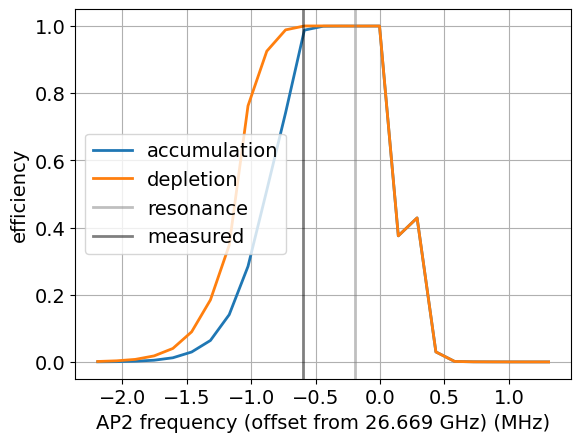

In [ ]:
fig, ax = plt.subplots()

ax.plot((detunings + paper_offset) / 1e6, appearance, lw=2, label="accumulation")

ax.plot(
    (detunings + paper_offset) / 1e6,
    removal,
    lw=2,
    label="depletion",
)

ax.axvline(paper_offset / 1e6, color="gray", lw=2, alpha=0.5, label="resonance")
ax.axvline(
    measured_resonance / 1e6 - common_offset / 1e6,
    color="black",
    lw=2,
    alpha=0.5,
    label="measured",
)

ax.set_xlabel("AP2 frequency (offset from 26.669 GHz) (MHz)")
ax.set_ylabel("efficiency")
ax.legend()
ax.grid()

In [ ]:
v0 = 184.0
sigma_v = 16.0
weights = np.exp(-0.5 * ((velocities - v0) / sigma_v) ** 2)
weights /= weights.sum()

In [ ]:
appearance = np.zeros_like(detunings)
removal = np.zeros_like(detunings)
for idv, (vel, res) in enumerate(res_velocity):
    pop_initial = res[4]
    pop_detected = np.array(res[-2])
    pop_detected += np.array(res[-1][-2])
    pop_detected += np.array(res[-1][-1])
    appearance += pop_detected * weights[idv]
    removal += (1 - pop_initial) * weights[idv]


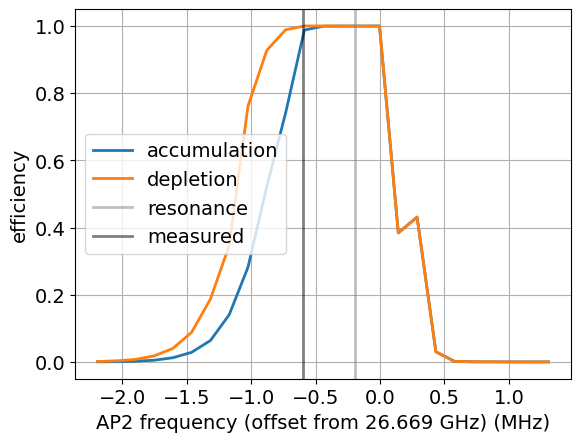

In [ ]:
fig, ax = plt.subplots()

ax.plot((detunings + paper_offset) / 1e6, appearance, lw=2, label="accumulation")

ax.plot(
    (detunings + paper_offset) / 1e6,
    removal,
    lw=2,
    label="depletion",
)

ax.axvline(paper_offset / 1e6, color="gray", lw=2, alpha=0.5, label="resonance")
ax.axvline(
    measured_resonance / 1e6 - common_offset / 1e6,
    color="black",
    lw=2,
    alpha=0.5,
    label="measured",
)

ax.set_xlabel("AP2 frequency (offset from 26.669 GHz) (MHz)")
ax.set_ylabel("efficiency")
ax.legend()
ax.grid()